# Super-Point Computation


> **Inputs:**
> - Wave spectra in `.nc` format from CAWCR or ERA5.  
>   These can optionally include prior satellite correction.
>
> **Outputs:**
> - `superPoint.nc`: reconstructed offshore spectrum saved in the `outputs` folder.  
>   Used as input for BinWaves **Reconstruction** and later **Validation**.



To account for all possible wave energy and avoid the shadowing effect caused by land, a **Super-Point** is created. This approach, proposed by Cagigal et al. (2021), aggregates energy from multiple surrounding points near the study site.

<center>
    <img src="./assets/superPoint.png" width="80%">
</center>

In this case, the virtual **Super-Point** is constructed using two directional spectra from the CAWCR (Centre for Australian Weather and Climate Research) hindcast dataset (Durrant et al., 2014; Smith et al., 2020).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import os.path as op
import sys
import xarray as xr
import numpy as np

In [2]:
files = [
    'inputs/44014_spec_WHACS_buoy_correted_15D.nc',
    'inputs/41025_spec_WHACS_buoy_correted_15D.nc',  
]
def load_station_data(ds: xr.Dataset) -> xr.Dataset:
    return ds.expand_dims("station")

# Use xr.open_mfdataset
stations_data = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim="station",
    preprocess=load_station_data,
).rename({'__xarray_dataarray_variable__': 'efth'})

# Define the actual station IDs
station_ids = [1911574,1904108]

# Replace the sequential station coordinates with actual station IDs
stations_data = stations_data.assign_coords(station=station_ids)
stations_data = stations_data.compute() 
stations_data

<xarray.Dataset> Size: 4GB
Dimensions:  (station: 2, time: 393720, freq: 29, dir: 24)
Coordinates:
  * time     (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq     (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir      (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
  * station  (station) int64 16B 1911574 1904108
Data variables:
    efth     (station, time, freq, dir) float64 4GB 1.786e-16 ... 7.241e-07

In [3]:
import importlib
import bluemath_tk.waves.superpoint 
importlib.reload(bluemath_tk.waves.superpoint)
from bluemath_tk.waves.superpoint import superpoint_calculation

sectors_for_each_station = {}
stations_id = [1911574,1904108]
stations_sector = [(300,120), (120, 300)]

for i, station_id in enumerate(stations_data.station.values):
    sectors_for_each_station[station_id] = stations_sector[i]

superpoint_result = superpoint_calculation(
    stations_data=stations_data,
    stations_dimension_name='station',
    sectors_for_each_station=sectors_for_each_station,
    overlap_angle=22.5,
)
# Virtual Coodinates
superpoint_result['latitude'] = 35.10
superpoint_result['longitude'] = -75.36
superpoint_result

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 393720, freq: 29, dir: 24)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1979-01-01 ... 2023-12-31T23:00:00
  * freq       (freq) float64 232B 0.035 0.03849 0.04232 ... 0.4135 0.4547 0.5
  * dir        (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    station    int64 8B 1911574
Data variables:
    efth       (time, freq, dir) float64 2GB 1.786e-16 4.636e-13 ... 1.942e-05
    latitude   float64 8B 35.1
    longitude  float64 8B -75.36

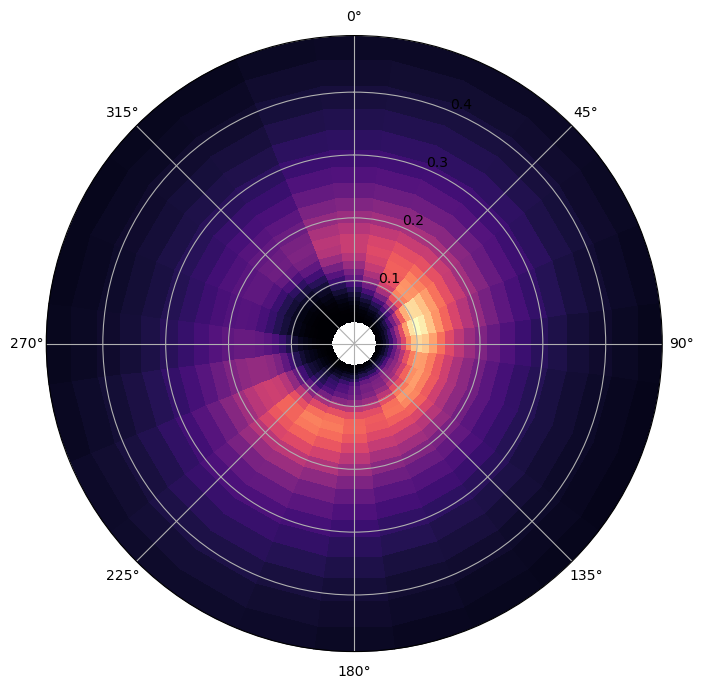

In [4]:
import importlib
import sys
sys.path.append('../utils')
from plotting import Plot_spectrum
Plot_spectrum(superpoint_result, average=True);

In [5]:
superpoint_result.to_netcdf("inputs/grid3_superPoint_15D.nc")